# 05 - YOLOX inference demo (MyYoloX)

Este notebook sigue el estilo de los notebooks de exploracion del proyecto, pero orientado a una prueba completa de inferencia con YOLOX: carga DICOM, preprocesado y deteccion de bounding boxes.

Requisito: ejecutar el kernel en el entorno del contenedor donde MyYoloX este instalado (`pip install -e /workspace/MyYoloX`).

In [9]:
import sys
import random
from pathlib import Path

import pydicom
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / "utils").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from utils.utils import find_dicom_images
from utils.yolox_interface import YOLOXNotebookInterface

from image.apply_windowing import apply_windowing
from image.calculate_windowing import (
                                get_dicom_voi_lut_params, 
                                normalize_photometric,
                                )

In [17]:
# Ajusta estas rutas a tu entorno
# DEFAULT_DATASET_DIR = Path('/workspace/Data/Mammo-MX/B1')
DEFAULT_DATASET_DIR = Path('/workspace/Data/INbreast/AllDICOMs/')
YOLOX_ROOT = project_root / 'MyYoloX'
EXP_FILE = YOLOX_ROOT / 'exps/default/yolox_nano.py'
CKPT_FILE = YOLOX_ROOT / 'archive/yolox_nano_416_roi_torch.pth'

DEVICE = 'gpu'  # cambia a 'cpu' si no tienes CUDA disponible
TSIZE = 416
CONF = 0.25
NMS = 0.45

print('project_root:', project_root)
print('dataset exists:', DEFAULT_DATASET_DIR.exists(), DEFAULT_DATASET_DIR)
print('exp exists:', EXP_FILE.exists(), EXP_FILE)
print('ckpt exists:', CKPT_FILE.exists(), CKPT_FILE)

project_root: /workspace
dataset exists: True /workspace/Data/INbreast/AllDICOMs
exp exists: True /workspace/MyYoloX/exps/default/yolox_nano.py
ckpt exists: True /workspace/MyYoloX/archive/yolox_nano_416_roi_torch.pth


In [18]:
dicom_paths = find_dicom_images(DEFAULT_DATASET_DIR, include_extensionless=True)
print(f'Total DICOM encontrados: {len(dicom_paths)}')

if not dicom_paths:
    raise RuntimeError('No se encontraron DICOMs. Revisa DEFAULT_DATASET_DIR.')

idx = random.randint(0, len(dicom_paths) - 1)
image_path = dicom_paths[idx]
print('Indice:', idx)
print('Imagen seleccionada:', image_path)

Total DICOM encontrados: 410
Indice: 258
Imagen seleccionada: /workspace/Data/INbreast/AllDICOMs/53586361_dda3c6969a34ff8e_MG_L_ML_ANON.dcm


In [19]:
metadata = pydicom.dcmread(image_path)
original_image = metadata.pixel_array
original_image, _ = normalize_photometric(original_image, metadata)

try:
    voilut = get_dicom_voi_lut_params(metadata)
    print(voilut)
    windowed_image = apply_windowing(
        original_image,
        window_width=voilut['window_width'],
        window_center=voilut['window_center'],
        voi_func=voilut['voi_lut_function'],
        y_min=float(original_image.min()),
        y_max=float(original_image.max()),
        backend='np_v2',
    )
except Exception:
    # Fallback: si no hay VOI LUT usable, usamos la imagen normalizada
    windowed_image = original_image

{'window_center': 1488, 'window_width': 700, 'rescale_intercept': 0.0, 'rescale_slope': 1.0, 'voi_lut_function': 'LINEAR'}


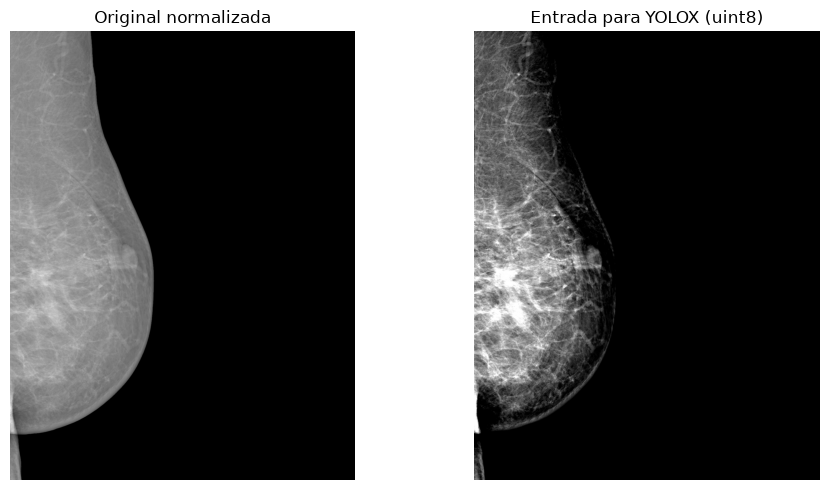

In [20]:
# Convertimos a uint8 para YOLOX
arr = windowed_image.astype('float32')
arr_min, arr_max = float(arr.min()), float(arr.max())
if arr_max > arr_min:
    arr = (arr - arr_min) / (arr_max - arr_min)
image_uint8 = (arr * 255.0).clip(0, 255).astype('uint8')

# YOLOXNotebookInterface acepta grayscale o RGB/BGR
image_for_yolo = image_uint8

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Original normalizada')
axes[0].axis('off')

axes[1].imshow(image_uint8, cmap='gray')
axes[1].set_title('Entrada para YOLOX (uint8)')
axes[1].axis('off')

plt.tight_layout()

In [21]:
predictor = YOLOXNotebookInterface(
    exp_file=str(EXP_FILE),
    ckpt_path=str(CKPT_FILE),
    device=DEVICE,
    conf=CONF,
    nms=NMS,
    tsize=TSIZE,
    fp16=False,
    yolox_root=str(YOLOX_ROOT),
)
print('Predictor inicializado correctamente')

Predictor inicializado correctamente


In [22]:
detections = predictor.predict(image_for_yolo, input_format='BGR')
print(f'Detecciones: {len(detections)}')

for i, det in enumerate(detections[:10]):
    print(f"[{i}] bbox={det['bbox_xyxy']} score={det['score']:.4f} class={det['class_name']}")

Detecciones: 1
[0] bbox=[8.46331787109375, 707.9578857421875, 1065.714111328125, 3002.97607421875] score=0.9866 class=person


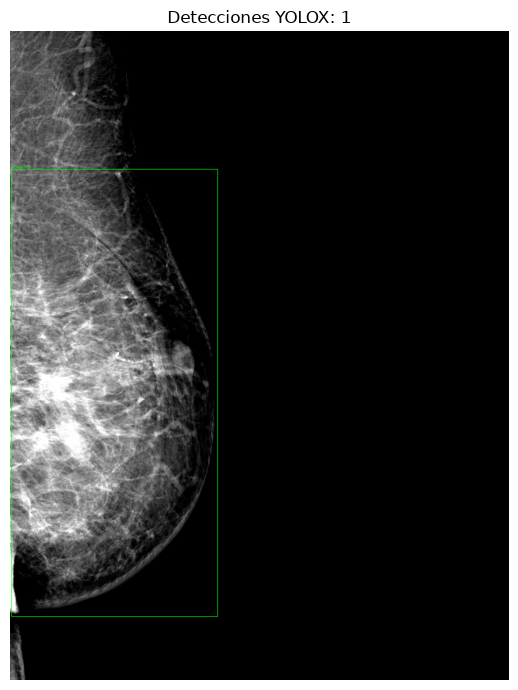

In [23]:
detections, vis_rgb = predictor.predict_with_image(image_for_yolo, input_format='BGR')

plt.figure(figsize=(7, 7))
plt.imshow(vis_rgb)
plt.title(f'Detecciones YOLOX: {len(detections)}')
plt.axis('off')
plt.tight_layout()